In [ ]:
from model_builder import ModelBuilder
#from model_testing.clean_impl_ebm.model_builder1 import ModelBuilder as ModelBuilder2

from preprocessing import Preprocessor
from plotting import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from model_testing.clean_impl.shapley_improved_other import ProcessAttributorSHAP
from model_testing.clean_impl.shapley_improved_other import ProcessAttributorSHAPMLP

#from shapley_improved import ProcessAttributorLinear
from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso

# from xgboost import XGBRFRegressor
#from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.neural_network import MLPRegressor

#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = [
    pd.read_parquet("../../workflows/siena12/stressng-custom-1782744477/datasets/process_interval_data.parquet")
    #pd.read_parquet("data/siena12/full_test/ampliseq_1_0607.parquet"),
    # pd.read_parquet("data/siena12/full_test/ampliseq_2_0607.parquet"),
    #pd.read_parquet("data/siena12/full_test/ampliseq_3_0707.parquet")
    #pd.read_parquet("runs/stressng-custom-1782744477/datasets/process_interval_data.parquet")
    #pd.read_parquet("data/siena12/test/rnaseq_siena12.parquet"),
    #pd.read_parquet("runs/nfcore-20260701T114734Z/datasets/rnaseq_1_02027.parquet"),
    #pd.read_parquet("runs/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"),
    #pd.read_parquet("runs/nfcore-20260704T110043Z/datasets/chipseq_2_0607.parquet"),
    #pd.read_parquet("runs/nfcore-20260703T215123Z/datasets/ampliseq_1_0607.parquet"),
    #pd.read_parquet("runs/nfcore-20260704T093159Z/datasets/ampliseq_2_0607.parquet"),
    #pd.read_parquet("runs/nfcore-20260706T112716Z/datasets/ampliseq_3_0707.parquet")
   # pd.read_parquet("data/siena12/full_test/ampliseq_triple_run.parquet")
]

In [3]:
data = pd.concat(data, ignore_index=True)

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


preprocessor_train = Preprocessor(data, features)
X_train, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 0 timestamps.


In [28]:
X_train

,delta_cpu_ns,delta_io_bytes,delta_net_send_bytes,context_switches,syscall_count,delta_rss_memory,delta_cpu_time_psutil,delta_cpu_time_proc,syscall_class_file,syscall_class_network,syscall_class_memory,syscall_class_process,syscall_class_other,syscall_class_sched,syscall_class_signal,syscall_class_time,delta_cycles,delta_cache_misses,delta_instructions,delta_branch_instructions
_time,,,,,,,,,,,,,,,,,,,,
2026-06-29 14:47:58+00:00,2.585282e+08,139264.0,476816.0,2562.0,32124.0,69632.0,0.0,3.630000e+09,9132.0,217.0,2.0,15.0,22526.0,0.0,132.0,141.0,0.0,0.0,0.0,0.0
2026-06-29 14:48:00+00:00,3.890915e+08,491520.0,593890.0,3457.0,42939.0,-206262272.0,0.0,8.760000e+09,9516.0,192.0,1.0,208.0,31016.0,10.0,79.0,96.0,0.0,0.0,0.0,0.0
2026-06-29 14:48:02+00:00,1.057240e+11,159744.0,481907.0,5474.0,54167.0,-18681856.0,0.0,1.158300e+11,14758.0,198.0,3.0,11.0,39628.0,133.0,42.0,188.0,0.0,0.0,0.0,0.0
2026-06-29 14:48:05+00:00,1.034357e+11,544768.0,723759.0,6624.0,46209.0,1081344.0,0.0,1.220400e+11,11184.0,219.0,8.0,81.0,34264.0,402.0,81.0,142.0,0.0,0.0,0.0,0.0
2026-06-29 14:48:07+00:00,1.166510e+11,290816.0,611126.0,4982.0,44202.0,110956544.0,0.0,1.113300e+11,10326.0,217.0,3.0,17.0,33387.0,7.0,66.0,141.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29 14:53:02+00:00,6.110968e+08,217088.0,755333.0,3166.0,52687.0,-633765888.0,0.0,2.071000e+10,14798.0,193.0,0.0,159.0,37182.0,136.0,42.0,188.0,0.0,0.0,0.0,0.0
2026-06-29 14:53:04+00:00,3.601767e+08,266240.0,756060.0,2834.0,42008.0,-279379968.0,0.0,4.560000e+09,10998.0,194.0,0.0,70.0,30470.0,99.0,42.0,141.0,0.0,0.0,0.0,0.0
2026-06-29 14:53:07+00:00,4.378175e+08,217088.0,873984.0,4078.0,42568.0,80904192.0,0.0,1.303000e+10,10726.0,201.0,0.0,185.0,31167.0,65.0,59.0,142.0,0.0,0.0,0.0,0.0


In [4]:
data.head()

,_time,pid,process_name,avg_power,context_switches,create_time,delta_branch_instructions,delta_cache_misses,delta_cpu_ns,delta_cpu_time_proc,...,syscall_count,syscall_class_process,syscall_class_sched,syscall_class_signal,syscall_class_memory,syscall_class_time,cgroup,cmdline,cwd,exe
0,2026-06-29 14:47:58+00:00,1,systemd,69.5,2.0,-1.0,0.0,0.0,87900.0,0.0,...,10.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2026-06-29 14:47:58+00:00,105,migration/15,69.5,2.0,-1.0,0.0,0.0,8809.0,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,2026-06-29 14:47:58+00:00,1094,kworker/18:1H-kblockd,69.5,2.0,-1.0,0.0,0.0,9990.0,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,2026-06-29 14:47:58+00:00,111,migration/16,69.5,2.0,-1.0,0.0,0.0,8800.0,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,2026-06-29 14:47:58+00:00,117,migration/17,69.5,2.0,-1.0,0.0,0.0,8430.0,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None


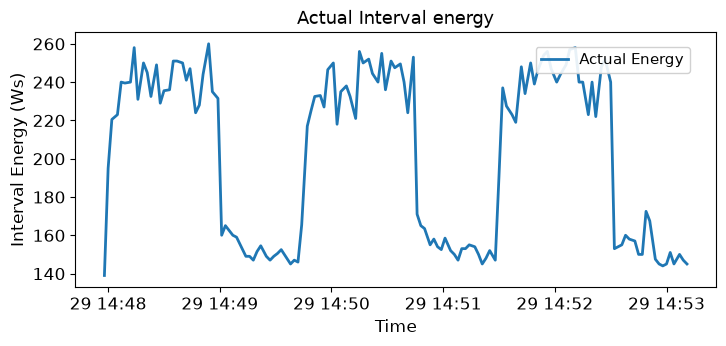

In [21]:
plot_dataset(t_train, y_train, "multi_training")


In [40]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
build_model_rf = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)


In [ ]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    #('decorrelate', CustomSpearmanFilter(threshold=0.80)),
 
    ('select_features', SelectFromModel(build_model_rf, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
X_train = automatic_feature_selection.fit_transform(X_train, y_train)
good_features_rf = X_train.columns.tolist()
print("Selected columns:")
print(good_features_rf)

#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_rss_memory', 'delta_cpu_time_proc']


In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
class SafeMLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self,activation="relu", solver="adam"):
        self.activation = activation
        self.solver = solver
        self.model = None

    def fit(self, X, y):
        self.model = MLPRegressor(activation="relu", solver="adam", random_state=42)
        
        self.model.fit(X, y)
        n_features = X.shape[1]
        all_importances = permutation_importance(self.model, X, y,
                           n_repeats=30,
                           random_state=0)
        
        # Now convert to numpy array and slice it for SelectFromModel
        print(np.array(all_importances))
        self.feature_importances_ = np.array(all_importances.importances_mean)
        return self

    def predict(self, X):
        return self.model.predict(X)



In [43]:
#These thresholds could be fine tuned
build_model = SafeMLPWrapper()
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    #('decorrelate', CustomSpearmanFilter(threshold=0.80)),
 
    ('select_features', SelectFromModel(build_model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
X_train = automatic_feature_selection.fit_transform(X_train, y_train)
good_features = X_train.columns.tolist()
print("Selected columns:")
print(good_features)

#plot_dataset(t_train, y_train, "multi_training")

{'importances_mean': array([ 4.08444624e+15,  1.55694754e+12,  1.85727116e+09, -1.59569290e+09,
        2.71594566e+13,  3.98116614e+15,  7.40608688e+08]), 'importances_std': array([5.01267583e+14, 1.38554287e+11, 1.49648208e+09, 2.03832720e+08,
       9.00390126e+12, 5.02884678e+14, 9.28450358e+07]), 'importances': array([[ 3.79011181e+15,  4.57125513e+15,  4.21504149e+15,
         3.42071770e+15,  2.59985697e+15,  3.97656661e+15,
         4.35943016e+15,  4.29996137e+15,  3.19058238e+15,
         3.96734657e+15,  4.42107127e+15,  4.80643971e+15,
         4.51831407e+15,  4.48821763e+15,  3.61287916e+15,
         4.56545194e+15,  4.58387413e+15,  4.38855388e+15,
         4.44089195e+15,  4.08561835e+15,  4.31803906e+15,
         4.32609746e+15,  3.23541611e+15,  3.95534769e+15,
         3.50686676e+15,  4.42401863e+15,  4.34315482e+15,
         3.63987484e+15,  4.44709151e+15,  4.03529807e+15],
       [ 1.45810894e+12,  1.69285421e+12,  1.52059669e+12,
         1.76148869e+12,  1.5335

In [ ]:
import joblib
import os
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

class ModelBuilder():

    def __init__(self, X_train, X_test, y_train, y_test, model, scaler):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.model = model
        self.scaler = scaler



    def _scale(self):
        #Try without scaling
        # self.scaler = None
        # self.X_train_scaled = self.X_train
        # self.X_test_scaled = self.X_test
        #self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train.values)
        self.X_test_scaled = self.scaler.transform(self.X_test.values)


    def _train(self):
        #self.model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        #self.model = Ridge(alpha=1.0)
        self.model.fit(self.X_train_scaled, self.y_train)
    
    def _test(self):
        self.y_pred = self.model.predict(self.X_test_scaled)
    
    def _evaluate(self):
        r2 = r2_score(self.y_test, self.y_pred)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        mean_energy = self.y_test.mean()
        mae_pct = (mae / mean_energy) * 100
        
        #print(f" Random Forest")
        print(f"  R² Score:  {r2:.4f}")
        print(f"  MAE:       {mae:.2f} Wh ({mae_pct:.2f}% of mean)")
        print("-" * 34)

    
    def _idle_power(self):
        #Predict an interval were all metrics are 0 to get an "idle prediction"
        zero_activity_interval = np.zeros((1, len(self.X_test_scaled[0])))
        zero_activity_interval = self.scaler.transform(zero_activity_interval)
        self.learned_idle_power = self.model.predict(zero_activity_interval)[0]
        print(f"The model's learned baseline idle interval energy is: {self.learned_idle_power:.2f} Wh")
        print("-" * 34)
        print("/n")

    def _save_model(self,path, filename):
        filepath = os.path.join(path, filename)
        bundle = {
            "scaler": self.scaler,
            "model": self.model
        }        
        joblib.dump(bundle, filepath)
        print(f"Model and scaler successfully saved to: {filepath}")
    
    def run_model(self,):
        self._scale()
        self._train()
        self._test()
        self._idle_power()
        self._evaluate()
        return self.y_pred, self.learned_idle_power
        
    
    def run_and_save_model(self, path="./", model_name="random_forest.joblib"):
        self._scale()
        self._train()
        self._test()
        self._evaluate()
        self._idle_power()
        #Dont svae rn
        #self._save_model(path, model_name)
        return self.y_pred, self.learned_idle_power

    

In [ ]:
# Temporary solution
#good_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']# R² 98% and 3,15% for the workflow data which is crazy


Dropped 0 timestamps.


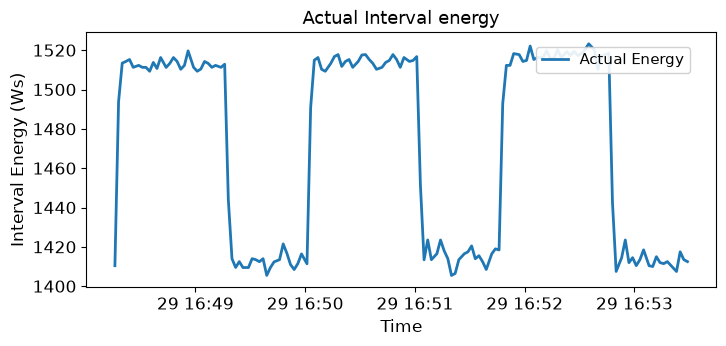

In [44]:
test_data = pd.read_parquet("../../workflows/gpu06/stressng-custom-1782751694/datasets/process_interval_data.parquet")

preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

plot_dataset(t_test, y_test, "multi_testing")

/home/johnhas/DistSys_Project/team-red/ProcessEnergyAccounting/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  R² Score:  -879.1478
  MAE:       1463.97 Wh (99.48% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 9.20 Wh
----------------------------------
/n


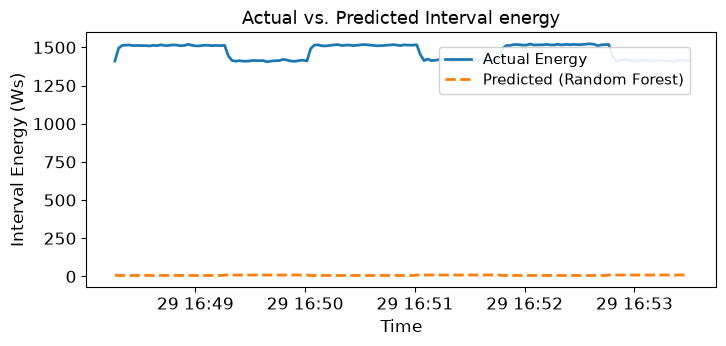

In [45]:
#idle_power_isactually idle interval energy
build_model_train = MLPRegressor(activation="relu", solver="adam", random_state=42)
builder = ModelBuilder(X_train, X_test, y_train, y_test, build_model_train, StandardScaler())
y_pred, learned_idle_power = builder.run_and_save_model()


plotter = Plotter(y_pred,y_test, t_test)#, window_start =50, window_end=200)
#plotter.plot_and_save("", "multi__pred_lasso")
plotter.plot_and_save("", "mlp_idea")

In [33]:
y_pred

array([48.47150014, 60.48942098, 58.59661876, 60.78853052, 61.33320723,
       60.00632312, 60.20849364, 59.94246777, 60.42567182, 60.65806397,
       60.36650551, 60.39471188, 59.37488718, 60.77677126, 60.1188135 ,
       60.19452511, 59.22768366, 60.48041593, 60.52902843, 56.76252286,
       58.65705161, 58.60712764, 58.69283377, 59.36048172, 59.29155219,
       60.05078189, 59.85107836, 58.77599539, 59.89599498, 68.29242867,
       68.40416593, 68.70001694, 68.58949483, 68.4316956 , 67.44021464,
       68.42668964, 68.46547868, 68.61308061, 68.40512324, 67.34942508,
       68.44529231, 68.08592612, 68.19801084, 67.74966389, 68.12980271,
       67.38198054, 68.04558886, 68.49341628, 67.90881297, 58.05656019,
       58.31576106, 56.92321419, 58.53446829, 59.47294554, 58.94329478,
       46.46673673, 55.34845306, 57.05493875, 58.2033833 , 56.26483783,
       58.54678253, 57.70350351, 58.27865633, 57.88850223, 58.2209163 ,
       58.01087043, 57.8645512 , 58.35331916, 58.30148395, 57.35

SHAP Base Power (Idle Baseline): 126.32 Ws


  0%|          | 0/147 [00:00<?, ?it/s]

actually aligned timezones
Top processes:  Index(['kworker/15:0-cgroup_free', 'ksoftirqd/4', 'kthreadd',
       'kworker/0:1H-kblockd', 'ksoftirqd/5', 'ksoftirqd/9', 'gdbus',
       'kworker/6:1H-kblockd'],
      dtype='str', name='base_name')
Top processes:  Index(['kworker/15:0-cgroup_free', 'ksoftirqd/4', 'kthreadd',
       'kworker/0:1H-kblockd', 'ksoftirqd/5', 'ksoftirqd/9', 'gdbus',
       'kworker/6:1H-kblockd'],
      dtype='str', name='base_name')


,pid,process_name,avg_power,context_switches,create_time,delta_branch_instructions,delta_cache_misses,delta_cpu_ns,delta_cpu_time_proc,delta_cpu_time_psutil,...,syscall_class_process,syscall_class_signal,syscall_count,syscall_class_sched,syscall_class_time,cgroup,cmdline,cwd,exe,attributed_dynamic_Wh
_time,,,,,,,,,,,,,,,,,,,,,
2026-06-29 16:48:16+00:00,1,systemd,705.0,2.0,-1.0,0.0,0.0,246495.0,0.0,0.0,...,0.0,0.0,10.0,NaN,0.0,None,None,None,None,-0.167357
2026-06-29 16:48:16+00:00,317494,python,705.0,4.0,-1.0,0.0,0.0,3380432.0,160000000.0,0.0,...,0.0,0.0,0.0,NaN,0.0,None,None,None,None,-0.011424
2026-06-29 16:48:16+00:00,317477,python,705.0,0.0,-1.0,0.0,0.0,0.0,160000000.0,0.0,...,0.0,0.0,18029.0,NaN,0.0,None,None,None,None,-39.487917
2026-06-29 16:48:16+00:00,317475,sudo,705.0,14.0,-1.0,0.0,0.0,338798.0,0.0,0.0,...,0.0,42.0,70.0,NaN,0.0,None,None,None,None,-4.271335
2026-06-29 16:48:16+00:00,317471,influxd,705.0,0.0,-1.0,0.0,0.0,0.0,20000000.0,0.0,...,0.0,0.0,0.0,NaN,0.0,None,None,None,None,-0.000787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29 16:53:29+00:00,263696,kworker/12:0-mm_percpu_wq,706.0,4.0,-1.0,0.0,0.0,37350.0,0.0,0.0,...,0.0,0.0,0.0,NaN,0.0,None,None,None,None,-0.006062
2026-06-29 16:53:29+00:00,268457,kworker/10:1-events,706.0,26.0,-1.0,0.0,0.0,552095.0,0.0,0.0,...,0.0,0.0,0.0,NaN,0.0,None,None,None,None,-0.039402
2026-06-29 16:53:29+00:00,271,kworker/10:1H-kblockd,706.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,NaN,0.0,None,None,None,None,0.000000


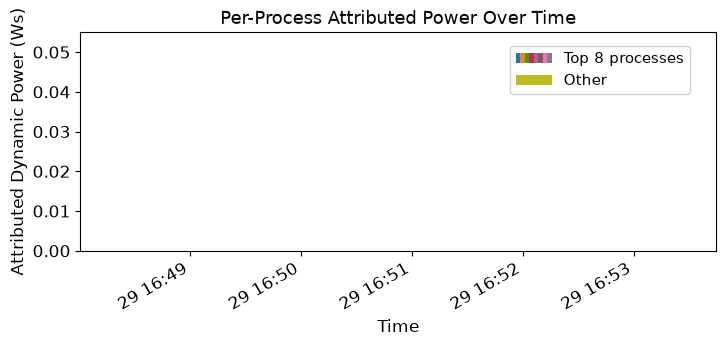

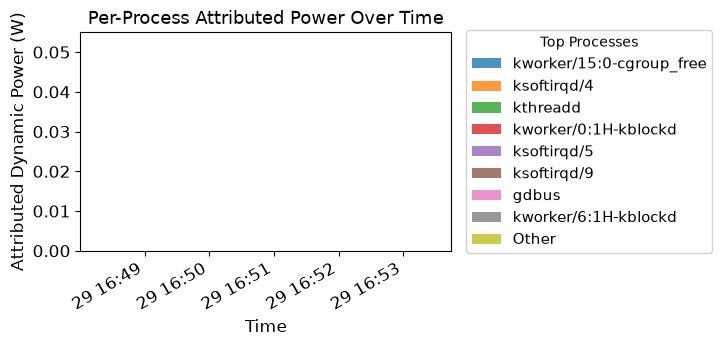

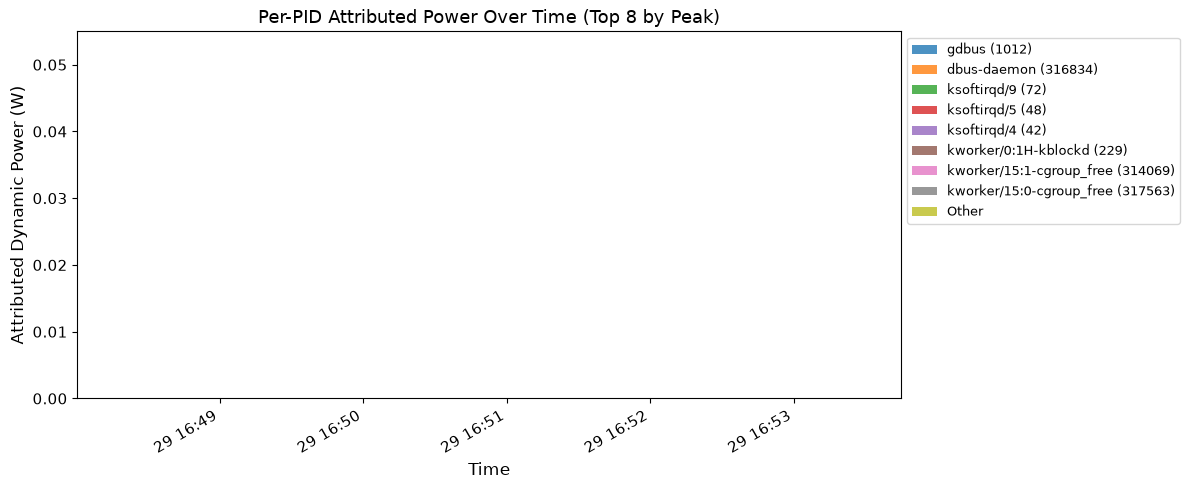

In [ ]:
#check if we ann pass this differently
attributor = ProcessAttributorSHAPMLP( builder.X_test_scaled, builder.model, builder.scaler)
attributor.attribute(X_test_unaggregated,good_features,t_test.values, "mlp_graphs_")